<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_08_grouping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: 2823 rows, 26 columns
Columns / Colonnes : ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'CITY', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE', 'TOTAL_ORDER_SALES', 'AVG_PRICE_ORDER', 'SALES_RATIO']

Top 10 products by total sales / Top 10 des produits par ventes totales :
  PRODUCTCODE      SALES
0    S18_3232  288245.42
1    S10_1949  191073.03
2    S10_4698  170401.07
3    S12_1108  168585.32
4    S18_2238  154623.95
5    S12_3891  145332.04
6    S24_3856  140626.90
7    S12_2823  140006.16
8    S18_1662  139421.97
9    S12_1099  137177.01


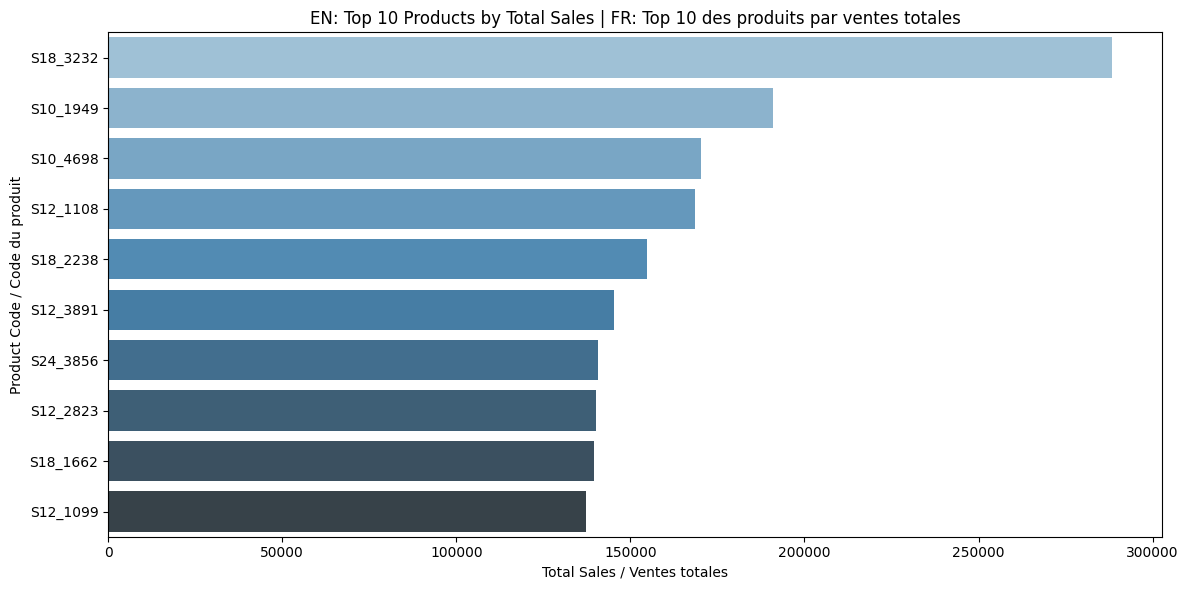


💾 File saved as 'sales_by_product.csv'
✅ Grouping complete! / Regroupement terminé !


In [4]:
# ===============================================================
# Day 08 – Grouping / Regroupement
# ===============================================================

"""
🎯 Objective / Objectif :
EN: Group sales data by product and analyze total revenue per product.
FR: Regrouper les données de ventes par produit et analyser le chiffre
    d'affaires total par produit.

📘 Description :
EN: This notebook focuses on aggregating sales data to identify the
    top-performing products based on total sales.
FR: Ce notebook se concentre sur l'agrégation des ventes afin d'identifier
    les produits les plus performants selon leurs ventes totales.

📅 Author / Auteur : Astrid Villalobos
📍 Montréal, QC
"""

# ===============================================================

# === 1. Imports / Importations ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load dataset / Charger le jeu de données ===
url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/sales_data_features.csv"
df = pd.read_csv(url, encoding="latin1")

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns / Colonnes : {list(df.columns)}")

# === 3. Group by product / Regrouper par produit ===
# Calculate total sales per product / Calculer les ventes totales par produit
sales_by_product = (
    df.groupby("PRODUCTCODE")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# === 4. Display summary / Afficher le résumé ===
print("\nTop 10 products by total sales / Top 10 des produits par ventes totales :")
print(sales_by_product.head(10))

# === 5. Visualization / Visualisation (Updated for Seaborn >= 0.14) ===
top_products = sales_by_product.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    x="SALES",
    y="PRODUCTCODE",
    hue="PRODUCTCODE",    # Apply color palette correctly
    data=top_products,
    palette="Blues_d",
    legend=False
)
plt.title("EN: Top 10 Products by Total Sales | FR: Top 10 des produits par ventes totales")
plt.xlabel("Total Sales / Ventes totales")
plt.ylabel("Product Code / Code du produit")
plt.tight_layout()
plt.show()

# === 6. Save grouped data / Sauvegarder les données regroupées ===
sales_by_product.to_csv("sales_by_product.csv", index=False)
print("\n💾 File saved as 'sales_by_product.csv'")
print("✅ Grouping complete! / Regroupement terminé !")
